In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Numerical Analysis

In [62]:
df = pd.read_csv('token_usage_log.csv')
print("Data Info:")
display(df.info())
print("\nData Description:")
display(df.describe())
print("\nFirst Few Rows:")
display(df.head())

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Timestamp               59 non-null     object
 1   Step                    59 non-null     object
 2   Input Tokens (Prompt)   59 non-null     int64 
 3   Output Tokens (Answer)  59 non-null     int64 
 4   Total Tokens            59 non-null     int64 
dtypes: int64(3), object(2)
memory usage: 2.4+ KB


None


Data Description:


,Input Tokens (Prompt),Output Tokens (Answer),Total Tokens
count,59.000000,59.000000,59.000000
mean,7877.203390,219.677966,10202.169492
std,10491.141475,284.715311,14603.502096
min,304.000000,3.000000,366.000000
25%,657.500000,19.500000,739.000000
50%,811.000000,124.000000,1014.000000
75%,22724.000000,280.500000,23069.500000
max,23761.000000,1526.000000,46895.000000



First Few Rows:


,Timestamp,Step,Input Tokens (Prompt),Output Tokens (Answer),Total Tokens
0,2026-04-19 16:44:36,Router (Topic Extraction),668,14,682
1,2026-04-19 16:44:39,Generator (Main RAG),486,205,691
2,2026-04-19 16:46:11,Router (Topic Extraction),661,25,686
3,2026-04-19 16:46:14,Generator (Main RAG),1240,100,1340
4,2026-04-19 17:03:17,Generator (Main RAG),455,268,723


In [63]:
df = df.rename(columns={
    'Input Tokens (Prompt)': 'Input Tokens',
    'Output Tokens (Answer)': 'Output Tokens'
})

df.head()

,Timestamp,Step,Input Tokens,Output Tokens,Total Tokens
0,2026-04-19 16:44:36,Router (Topic Extraction),668,14,682
1,2026-04-19 16:44:39,Generator (Main RAG),486,205,691
2,2026-04-19 16:46:11,Router (Topic Extraction),661,25,686
3,2026-04-19 16:46:14,Generator (Main RAG),1240,100,1340
4,2026-04-19 17:03:17,Generator (Main RAG),455,268,723


In [64]:
df['Extra Tokens'] = df['Total Tokens'] - df['Input Tokens'] - df['Output Tokens']
df['Model'] = df['Step'].apply(lambda x: 'Naive' if 'Generator (NAIVE RAG - Full DB)' in x else 'Router Based')

## Plots

### Cmap

In [65]:
# Colormap for each Step category
router_based = "#3cb6aed6"
full_db = "#f93e3e"

step_cmap = {
    'Router (Topic Extraction)': router_based,
    'Generator (Main RAG)': router_based,
    'Generator (NAIVE RAG - Full DB)': full_db
}

model_cmap = {
    'Router Based': router_based,
    'Naive': full_db
}

### Comparison

#### Model Type Freq

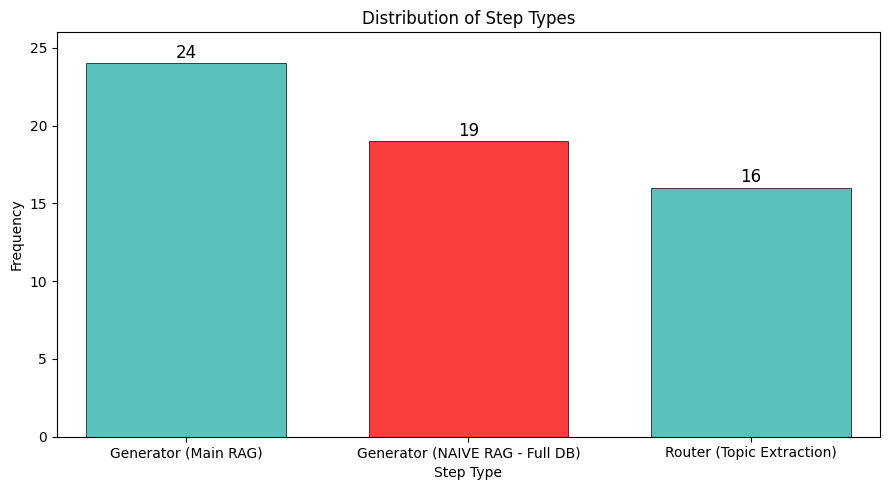

In [ ]:
step_counts = df['Step'].value_counts().sort_index()
bar_colors = [step_cmap.get(step, '#607d8b') for step in step_counts.index]

plt.figure(figsize=(9, 5))
x = np.arange(len(step_counts)) * 0.48
bars = plt.bar(x, 
               step_counts.values, 
               width=0.34, 
               color=bar_colors,
               edgecolor='black',
               linewidth=0.5)

# Show value labels on top of each bar
for bar, v in zip(bars, step_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        v + 0.1,
        str(v),
        ha='center',
        va='bottom',
        fontsize=12
    )

plt.xticks(x, step_counts.index)
plt.xlim(x.min() - 0.22, x.max() + 0.22)
plt.ylim(0, step_counts.max() + 2)
plt.title('Distribution of Step Types')
plt.xlabel('Step Type')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

#### Average token per model

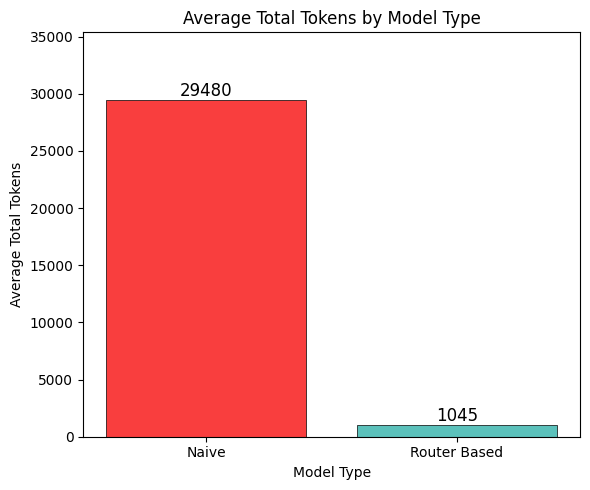

In [75]:
total_token_df = df.groupby('Model')['Total Tokens'].mean().reset_index()

bar_colors = [model_cmap.get(model, '#607d8b') for model in total_token_df['Model']]

plt.figure(figsize=(6, 5))
bars = plt.bar(total_token_df['Model'], 
               total_token_df['Total Tokens'], 
               color=bar_colors,
               edgecolor='black',
               linewidth=0.5)

# Show value labels on top of each bar
for bar, v in zip(bars, total_token_df['Total Tokens']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        v + 0.1,
        f"{v:.0f}",
        ha='center',
        va='bottom',
        fontsize=12
    )
plt.title('Average Total Tokens by Model Type')
plt.xlabel('Model Type')
plt.ylabel('Average Total Tokens')
plt.ylim(0, total_token_df['Total Tokens'].max() * 1.2)
plt.tight_layout()

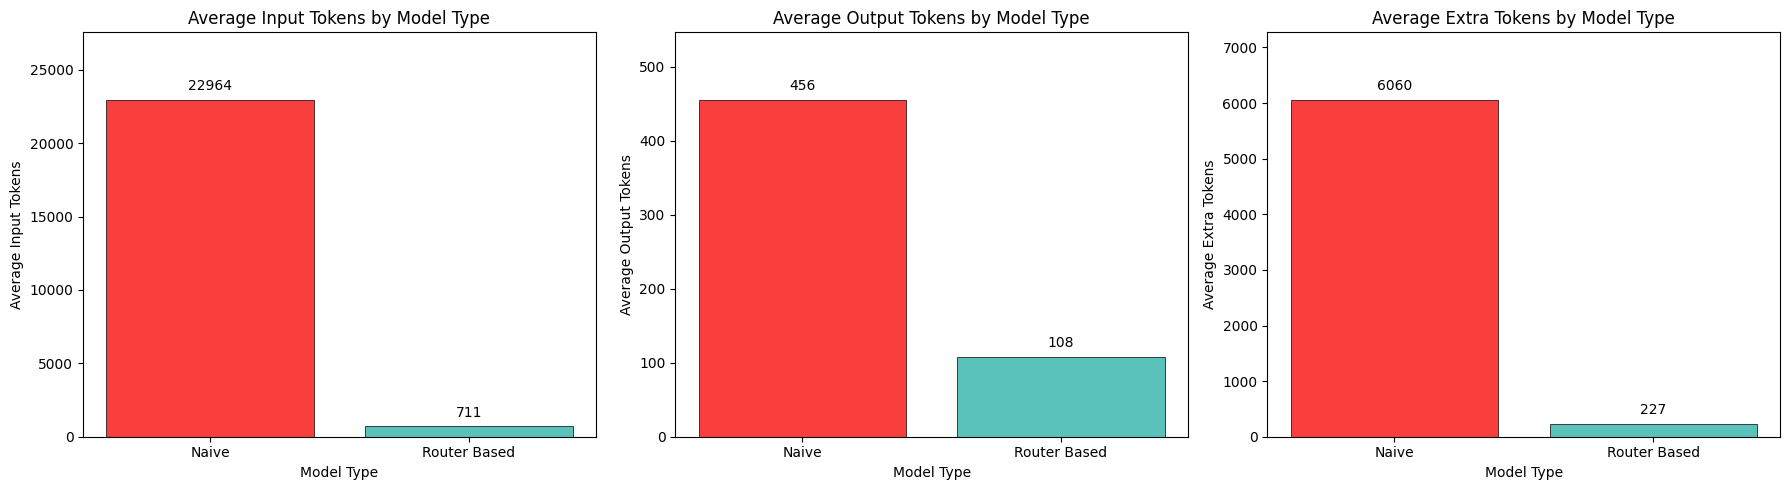

In [76]:
metrics = ['Input Tokens', 'Output Tokens', 'Extra Tokens']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric in zip(axes, metrics):
    metric_df = df.groupby('Model')[metric].mean().reset_index()
    bar_colors = [model_cmap.get(model, '#607d8b') for model in metric_df['Model']]

    bars = ax.bar(
        metric_df['Model'],
        metric_df[metric],
        color=bar_colors,
        edgecolor='black',
        linewidth=0.5
    )

    for bar, v in zip(bars, metric_df[metric]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            v + (metric_df[metric].max() * 0.02),
            f"{v:.0f}",
            ha='center',
            va='bottom',
            fontsize=10
        )

    ax.set_title(f'Average {metric} by Model Type')
    ax.set_xlabel('Model Type')
    ax.set_ylabel(f'Average {metric}')
    ax.set_ylim(0, metric_df[metric].max() * 1.2)

plt.tight_layout()
plt.show()